In [2]:
import pandas as pd
import boto3

In [3]:
from pathlib import Path

bucket = "dsan6000-saa464"

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix="wikipedia-hourly/"
)

files = [
    obj["Key"]
    for obj in response["Contents"]
]

files

['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet',
 'wikipedia-hourly/20260901_070000.parquet',
 'wikipedia-hourly/20260901_080000.parquet',
 'wikipedia-hourly/20260901_090000.parquet',
 'wikipedia-hourly/20260901_100000.parquet',
 'wikipedia-hourly/20260901_110000.parquet',
 'wikipedia-hourly/20260901_120000.parquet',
 'wikipedia-hourly/20260901_130000.parquet',
 'wikipedia-hourly/20260901_140000.parquet',
 'wikipedia-hourly/20260901_150000.parquet',
 'wikipedia-hourly/20260901_160000.parquet',
 'wikipedia-hourly/20260901_170000.parquet',
 'wikipedia-hourly/20260901_180000.parquet',
 'wikipedia-hourly/20260901_190000.parquet',
 'wikipedia-hourly/20260901_200000.parquet',
 'wikipedia-hourly/20260901_210000.parquet',
 'wikipedia-hourly/20260901_220000.parquet',
 'wikipedia-hourly/20260901_230000.parquet',
 'wikipedia-hourly/20260902_000000.parquet',
 'wikipedia-hourly/20260902_010000.parquet',
 'wikipedi

In [9]:
dfs = []

for file in files:
    path = f"s3://{bucket}/{file}"
    hour_df = pd.read_parquet(path)
    dfs.append(hour_df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(119708, 29)


In [10]:
df.columns.tolist()

['datetime',
 '$schema',
 'meta',
 'id',
 'type',
 'namespace',
 'title',
 'title_url',
 'comment',
 'timestamp',
 'user',
 'bot',
 'notify_url',
 'minor',
 'length',
 'revision',
 'server_url',
 'server_name',
 'server_script_path',
 'wiki',
 'parsedcomment',
 'log_id',
 'log_type',
 'log_action',
 'log_params',
 'log_action_comment',
 'patrolled',
 'file_ts',
 'file_ts_str']

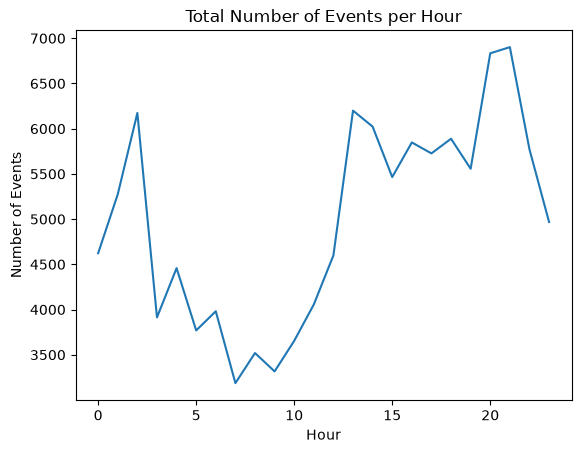

In [12]:
df["datetime"] = pd.to_datetime(df["datetime"])

hourly_events = df.groupby(df["datetime"].dt.hour).size()

sns.lineplot(x=hourly_events.index, y=hourly_events.values)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Total Number of Events per Hour")

plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")

plt.show()

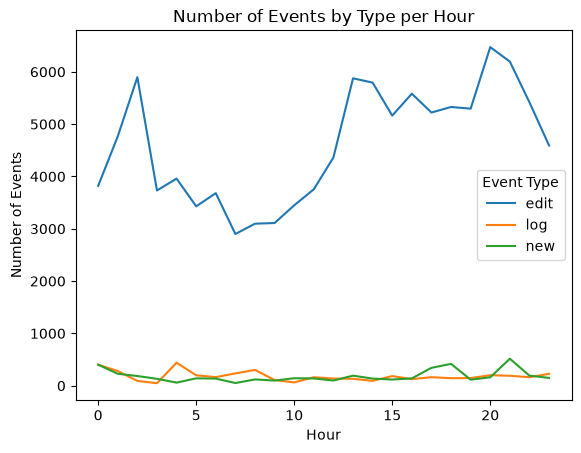

In [13]:
hourly_by_type = (
    df.groupby([df["datetime"].dt.hour, "type"])
      .size()
      .reset_index(name="count")
)

sns.lineplot(
    data=hourly_by_type,
    x="datetime",
    y="count",
    hue="type"
)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Number of Events by Type per Hour")
plt.legend(title="Event Type")

plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")

plt.show()

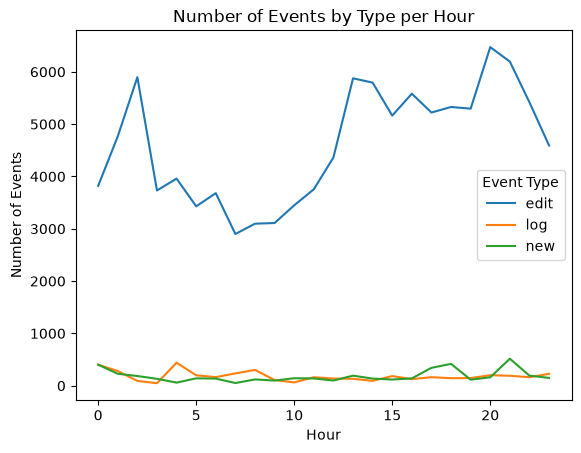

In [14]:
hourly_by_type = (
    df.groupby([df["datetime"].dt.hour, "type"])
      .size()
      .reset_index(name="count")
)

sns.lineplot(
    data=hourly_by_type,
    x="datetime",
    y="count",
    hue="type"
)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Number of Events by Type per Hour")
plt.legend(title="Event Type")

plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")

plt.show()